In [1]:
def generate_string(base, indices):
    for index in indices:
        index = int(index)
        base = base[:index+1] + base + base[index+1:]
    return base

In [3]:
def parse_input_file(file_path):
    with open(file_path, 'r') as f:
        lines = [line.strip() for line in f.readlines()]
    
    i = 0
    s1 = lines[i]
    i += 1
    j = 0
    s1_indices = []
    while lines[i].isdigit():
        s1_indices.append(int(lines[i]))
        j += 1
        i += 1

    s2 = lines[i]
    i += 1
    s2_indices = []
    while i < len(lines) and lines[i].isdigit():
        s2_indices.append(int(lines[i]))
        i += 1

    final_s1 = generate_string(s1, s1_indices)
    final_s2 = generate_string(s2, s2_indices)
    return final_s1, final_s2

In [4]:
alpha = {
    'A': {'A': 0,   'C': 110, 'G': 48,  'T': 94},
    'C': {'A': 110, 'C': 0,   'G': 118, 'T': 48},
    'G': {'A': 48,  'C': 118, 'G': 0,   'T': 110},
    'T': {'A': 94,  'C': 48,  'G': 110, 'T': 0}
}
delta = 30

In [6]:
def seq_align_basic(X, Y):
    m,n = len(X), len(Y)
    opt = [[0]*(n+1) for i in range(m+1)]
    for i in range(m+1):
        opt[i][0] = i * delta
    for j in range(n+1):
        opt[0][j] = j * delta
        
    for i in range(1,m+1):
        for j in range(1,n+1):
            c_sub = opt[i-1][j-1] + alpha[X[i-1]][Y[j-1]]
            c_del = opt[i-1][j] + delta
            c_ins = opt[i][j-1] + delta
            opt[i][j] = min(c_sub, c_del, c_ins)
            
    X1,Y1 = "",""
    i,j = m,n
    while i>0 and j>0:
        if opt[i][j] == opt[i-1][j-1] + alpha[X[i-1]][Y[j-1]]:
            X1 = X[i-1] + X1
            Y1 = Y[j-1] + Y1
            i -= 1
            j -= 1
        elif opt[i][j] == opt[i-1][j] + delta:
            X1 = X[i-1] + X1
            Y1 = "_" + Y1
            i -= 1
        else:
            X1 = "_" + X1
            Y1 = Y[j-1] + Y1
            j -= 1
            
    while i>0:
        X1 = X[i-1] + X1
        Y1 = "_" + Y1
        i -= 1
        
    while j>0:
        Y1 = Y[j-1] + Y1
        X1 = "_" + X1
        j -= 1
        
    return opt[m][n], X1, Y1

In [9]:
X,Y = parse_input_file('datapoints/in2.txt')
print(X)
print(Y)

CTTCTCTTCTTCTTCCCTTCCTCTTCCCTTCC
CCCCGACGACCCCCGACGACCGACGACGACGA


In [10]:
score, X1, Y1 = seq_align_basic(X, Y)
print(score)
print(X1)
print(Y1)

960
CTTCTCTTC__TTC__TTCCCTTCC__TC__TTCC__C__TTC__C__
C__C_C__CGA__CGA__CCC__CCGA_CGA__CCGACGA__CGACGA


In [23]:
def split_Y(X, Y, reverse=False):
    if reverse:
        X = X[::-1]
        Y = Y[::-1]
        
    m, n = len(X), len(Y)
    prev = [i*delta for i in range(n+1)]
    
    for i in range(1, m+1):
        cur = [0] * (n+1)
        cur[0] = i*delta
        for j in range(1, n+1):
            c_sub = prev[j-1] + alpha[X[i-1]][Y[j-1]]
            c_del = prev[j] + delta
            c_ins = cur[j-1] + delta
            cur[j] = min(c_sub, c_del, c_ins)
        prev = cur
    return prev

In [31]:
def divide_and_conquer(X, Y):
    if len(X) == 0:
        return '_' * len(Y), Y
    if len(Y) == 0:
        return X, '_' * len(X)
    if len(X) <= 1 or len(Y) <= 3:
        score, X, Y = seq_align_basic(X, Y)
        return X, Y
    
    mid = len(X)//2
    
    y_l = split_Y(X[:mid], Y)
    y_r = split_Y(X[mid:], Y, reverse=True)
    
    total = [l + r for l,r in zip(y_l, reversed(y_r))]
    split_index = total.index(min(total))
    
    X_l, Y_l = divide_and_conquer(X[:mid], Y[:split_index])
    X_r, Y_r = divide_and_conquer(X[mid:], Y[split_index:])
    
    return X_l + X_r, Y_l + Y_r

In [24]:
def seq_align_memeff(X, Y):
    X1,Y1 = divide_and_conquer(X, Y)
    cost = 0
    for x,y in zip(X1,Y1):
        if x=='_' or y=='_':
            cost += delta
        else:
            cost += alpha[x][y]
    return cost, X1, Y1

In [26]:
score, X1, Y1 = seq_align_memeff(X, Y)
print(score)
print(X1)
print(Y1)

960
CTTCTCTTC__TTC__TTCCCTTCC__TCT__TCC__C__TTC__C__
C__C_C__CGA__CGA__CCC__CCGA_C_GA_CCGACGA__CGACGA


In [13]:
!pip install psutil

In [14]:
import time
import psutil

def get_memory_usage_kb():
    return int(psutil.Process().memory_info().rss / 1024)

In [21]:
def run(input_file, output_file, method):
    X, Y = parse_input_file(input_file)
    start_time = time.time()
    cost, X1, X2 = method(X, Y)
    end_time = time.time()
    mem_kb = get_memory_usage_kb()
    time_ms = (end_time - start_time) * 1000

    with open(output_file, 'w+') as f:
        f.write(f"{cost}\n")
        f.write(f"{X1}\n")
        f.write(f"{X2}\n")
        f.write(f"{time_ms}\n")
        f.write(f"{mem_kb}\n")

In [34]:
run("datapoints/in10.txt", "outputs/out_10.txt", seq_align_basic)

In [35]:
run("datapoints/in10.txt", "outputs/out_me_10.txt", seq_align_memeff)

Benchmarking 15 files across 9 thresholds...


--- Threshold: 1 ---
in1.txt              ✅ Time: 1.0 ms | Mem: 27260.0 KB | Cost: 168
in10.txt             ✅ Time: 958.8 ms | Mem: 27472.0 KB | Cost: 27648
in11.txt             ✅ Time: 1613.0 ms | Mem: 27672.0 KB | Cost: 32748
in12.txt             ✅ Time: 2602.2 ms | Mem: 27608.0 KB | Cost: 32352
in13.txt             ✅ Time: 3616.0 ms | Mem: 27468.0 KB | Cost: 61440
in14.txt             ✅ Time: 5085.0 ms | Mem: 27604.0 KB | Cost: 29532
in15.txt             ✅ Time: 6735.5 ms | Mem: 27616.0 KB | Cost: 46320
in2.txt              ✅ Time: 2.0 ms | Mem: 27900.0 KB | Cost: 960
in3.txt              ✅ Time: 11.0 ms | Mem: 27760.0 KB | Cost: 1848
in4.txt              ✅ Time: 29.5 ms | Mem: 27640.0 KB | Cost: 5760
in5.txt              ✅ Time: 71.1 ms | Mem: 27764.0 KB | Cost: 7680
in6.txt              ✅ Time: 114.1 ms | Mem: 27312.0 KB | Cost: 5244
in7.txt              ✅ Time: 302.6 ms | Mem: 27772.0 KB | Cost: 7728
in8.txt              ✅ Time: 403.

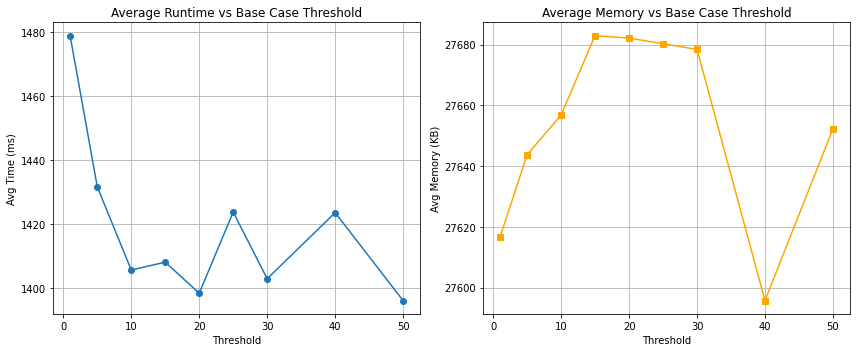

In [36]:
import os
import subprocess
import matplotlib.pyplot as plt
from statistics import mean

# === CONFIG ===
thresholds = [1, 5, 10, 15, 20, 25, 30, 40, 50]
data_folder = "datapoints"  # Folder with 15 input files
output_path = "temp_output.txt"

# === COLLECT ALL INPUT FILES ===
input_files = [os.path.join(data_folder, f) for f in os.listdir(data_folder) if f.endswith(".txt")]
input_files.sort()  # optional: to ensure consistent order

# === STORAGE ===
results = {
    t: {'time': [], 'memory': [], 'costs': []}
    for t in thresholds
}

print(f"Benchmarking {len(input_files)} files across {len(thresholds)} thresholds...\n")

for t in thresholds:
    print(f"\n--- Threshold: {t} ---")
    for input_file in input_files:
        result = subprocess.run(
            ['python3', 'efficient_3.py', input_file, output_path, str(t)],
            capture_output=True, text=True
        )

        if result.returncode != 0:
            print(f"❌ {input_file} failed at threshold {t}")
            print(result.stderr)
            continue

        with open(output_path, 'r') as f:
            lines = f.readlines()
            cost = int(lines[0].strip())
            time_ms = float(lines[3].strip())
            mem_kb = float(lines[4].strip())

        results[t]['time'].append(time_ms)
        results[t]['memory'].append(mem_kb)
        results[t]['costs'].append(cost)

        print(f"{os.path.basename(input_file):<20} ✅ Time: {time_ms:.1f} ms | Mem: {mem_kb:.1f} KB | Cost: {cost}")

# === PLOT AVERAGE TIME + MEMORY ===
avg_times = [mean(results[t]['time']) for t in thresholds]
avg_memory = [mean(results[t]['memory']) for t in thresholds]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, avg_times, marker='o')
plt.title("Average Runtime vs Base Case Threshold")
plt.xlabel("Threshold")
plt.ylabel("Avg Time (ms)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(thresholds, avg_memory, marker='s', color='orange')
plt.title("Average Memory vs Base Case Threshold")
plt.xlabel("Threshold")
plt.ylabel("Avg Memory (KB)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [39]:
import os
import subprocess
import matplotlib.pyplot as plt

def generate_string(base, indices):
    for index in indices:
        index = int(index)
        base = base[:index+1] + base + base[index+1:]
    return base

def parse_input_file_len(file_path):
    with open(file_path, 'r') as f:
        lines = [line.strip() for line in f.readlines()]

    i = 0
    s1 = lines[i]
    i += 1
    s1_indices = []
    while lines[i].isdigit():
        s1_indices.append(int(lines[i]))
        i += 1
    s2 = lines[i]
    i += 1
    s2_indices = []
    while i < len(lines) and lines[i].isdigit():
        s2_indices.append(int(lines[i]))
        i += 1

    s1_full = generate_string(s1, s1_indices)
    s2_full = generate_string(s2, s2_indices)
    return len(s1_full) + len(s2_full)

# === BENCHMARKING ===
data_folder = "datapoints"
output_path_basic = "out_basic.txt"
output_path_eff = "out_eff.txt"
threshold = "30"

files = sorted(os.listdir(data_folder))
problem_sizes = []
time_basic = []
time_eff = []
mem_basic = []
mem_eff = []

print(f"{'File':<20} {'Size':>6} {'Basic (ms)':>12} {'Eff (ms)':>10} {'Basic (KB)':>12} {'Eff (KB)':>10}")

for fname in files:
    input_path = os.path.join(data_folder, fname)
    size = parse_input_file_len(input_path)
    problem_sizes.append(size)

    # Run basic
    subprocess.run(['python3', 'basic_3.py', input_path, output_path_basic])
    with open(output_path_basic, 'r') as f:
        lines = f.readlines()
        time_b = float(lines[3].strip())
        mem_b = float(lines[4].strip())
        time_basic.append(time_b)
        mem_basic.append(mem_b)

    # Run efficient
    subprocess.run(['python3', 'efficient_3.py', input_path, output_path_eff, threshold])
    with open(output_path_eff, 'r') as f:
        lines = f.readlines()
        time_e = float(lines[3].strip())
        mem_e = float(lines[4].strip())
        time_eff.append(time_e)
        mem_eff.append(mem_e)

    print(f"{fname:<20} {size:>6} {time_b:10.2f} {time_e:10.2f} {mem_b:10.2f} {mem_e:10.2f}")


File                   Size   Basic (ms)   Eff (ms)   Basic (KB)   Eff (KB)
in1.txt                  16       0.00       0.00   27460.00   27724.00
in10.txt               1536     613.06     863.88   32856.00   27484.00
in11.txt               2048    1007.57    1575.59   36372.00   27624.00
in12.txt               2560    1909.66    2827.13   41292.00   27076.00
in13.txt               3072    2335.13    5034.32   47412.00   27428.00
in14.txt               3584    3188.72    4962.75   55056.00   27624.00
in15.txt               3968    3849.86    6148.57   61948.00   27576.00
in2.txt                  64       1.01       1.00   27504.00   27668.00
in3.txt                 128       3.01       4.01   27684.00   27680.00
in4.txt                 256      14.02      21.53   27868.00   27752.00
in5.txt                 384      30.58      48.58   27900.00   27792.00
in6.txt                 512      53.03      88.58   28504.00   27728.00
in7.txt                 768     135.63     208.55   28856.00

In [40]:
# Sort all lists by problem_sizes
combined = sorted(zip(problem_sizes, time_basic, time_eff, mem_basic, mem_eff))
problem_sizes, time_basic, time_eff, mem_basic, mem_eff = map(list, zip(*combined))

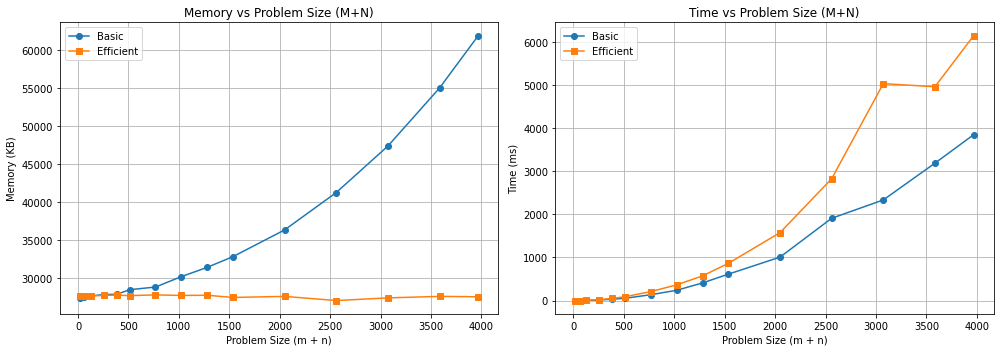

In [41]:
plt.figure(figsize=(14, 5))

# Memory Plot
plt.subplot(1, 2, 1)
plt.plot(problem_sizes, mem_basic, marker='o', label="Basic")
plt.plot(problem_sizes, mem_eff, marker='s', label="Efficient")
plt.title("Memory vs Problem Size (M+N)")
plt.xlabel("Problem Size (m + n)")
plt.ylabel("Memory (KB)")
plt.legend()
plt.grid(True)

# Time Plot
plt.subplot(1, 2, 2)
plt.plot(problem_sizes, time_basic, marker='o', label="Basic")
plt.plot(problem_sizes, time_eff, marker='s', label="Efficient")
plt.title("Time vs Problem Size (M+N)")
plt.xlabel("Problem Size (m + n)")
plt.ylabel("Time (ms)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
